In [ ]:
import os
import glob
import random
import h5py
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version :", torch.__version__)
print("Device          :", device)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))

PyTorch version : 2.11.0+cpu
Device          : cpu


In [10]:
DATA_ROOT = "/content/drive/MyDrive/microgen3D/sample_CH_two_phase"

TRAIN_DIR = os.path.join(DATA_ROOT, "train")

H5_FILES = sorted(
    glob.glob(os.path.join(TRAIN_DIR, "*.h5"))
)

print("Number of H5 files:", len(H5_FILES))

if len(H5_FILES) == 0:
    raise FileNotFoundError(
        f"No H5 files found in:\n{TRAIN_DIR}"
    )

Number of H5 files: 9


In [12]:
sample_index = []

for file_path in H5_FILES:

    with h5py.File(file_path, "r") as f:

        for key in f.keys():

            sample_index.append(
                (file_path, key)
            )


print("Total microstructures:", len(sample_index))

print("\nFirst 10 samples:")

for item in sample_index[:10]:
    print(item)

Total microstructures: 90

First 10 samples:
('/content/drive/MyDrive/microgen3D/sample_CH_two_phase/train/part_1.h5', '1124')
('/content/drive/MyDrive/microgen3D/sample_CH_two_phase/train/part_1.h5', '14')
('/content/drive/MyDrive/microgen3D/sample_CH_two_phase/train/part_1.h5', '2342')
('/content/drive/MyDrive/microgen3D/sample_CH_two_phase/train/part_1.h5', '3477')
('/content/drive/MyDrive/microgen3D/sample_CH_two_phase/train/part_1.h5', '3919')
('/content/drive/MyDrive/microgen3D/sample_CH_two_phase/train/part_1.h5', '3925')
('/content/drive/MyDrive/microgen3D/sample_CH_two_phase/train/part_1.h5', '4753')
('/content/drive/MyDrive/microgen3D/sample_CH_two_phase/train/part_1.h5', '6329')
('/content/drive/MyDrive/microgen3D/sample_CH_two_phase/train/part_1.h5', '7173')
('/content/drive/MyDrive/microgen3D/sample_CH_two_phase/train/part_1.h5', '7374')


In [13]:
# ============================================================
# 2B. VERIFY DATA
# ============================================================

file_path, key = sample_index[0]

with h5py.File(file_path, "r") as f:

    volume = np.array(f[key])


print("Example file :", file_path)
print("Example key  :", key)

print("\nShape        :", volume.shape)
print("dtype        :", volume.dtype)
print("min          :", volume.min())
print("max          :", volume.max())
print("mean         :", volume.mean())
print("unique       :", np.unique(volume))

Example file : /content/drive/MyDrive/microgen3D/sample_CH_two_phase/train/part_1.h5
Example key  : 1124

Shape        : (128, 128, 64)
dtype        : int64
min          : 0
max          : 1
mean         : 0.6501588821411133
unique       : [0 1]


In [14]:
# ============================================================
# 2C. 90% TRAIN / 10% VALIDATION
# ============================================================

train_index, val_index = train_test_split(
    sample_index,
    test_size=0.10,
    random_state=SEED,
    shuffle=True
)

print("Total samples      :", len(sample_index))
print("Training samples   :", len(train_index))
print("Validation samples :", len(val_index))

print("\nTraining fraction   :", len(train_index) / len(sample_index))
print("Validation fraction :", len(val_index) / len(sample_index))

Total samples      : 90
Training samples   : 81
Validation samples : 9

Training fraction   : 0.9
Validation fraction : 0.1


In [15]:
# ============================================================
# 2D. PYTORCH DATASET
# ============================================================

class MicrostructureDataset(Dataset):

    def __init__(self, index):
        self.index = index

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):

        file_path, key = self.index[idx]

        with h5py.File(file_path, "r") as f:

            volume = np.array(
                f[key],
                dtype=np.float32
            )

        # ----------------------------------------------------
        # Original:
        #       0, 1
        #
        # Convert to:
        #      -1, +1
        #
        # because Generator uses tanh.
        # ----------------------------------------------------

        volume = volume * 2.0 - 1.0

        # ----------------------------------------------------
        # Conv3D expects:
        #
        # (channels, depth, height, width)
        #
        # Current:
        # (128, 128, 64)
        #
        # Add channel dimension.
        # ----------------------------------------------------

        volume = torch.from_numpy(volume)

        volume = volume.unsqueeze(0)

        return volume


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset = MicrostructureDataset(train_index)
val_dataset = MicrostructureDataset(val_index)


# ------------------------------------------------------------
# Batch size
# ------------------------------------------------------------

BATCH_SIZE = 2


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


print("Training batches   :", len(train_loader))
print("Validation batches :", len(val_loader))

Training batches   : 41
Validation batches : 5


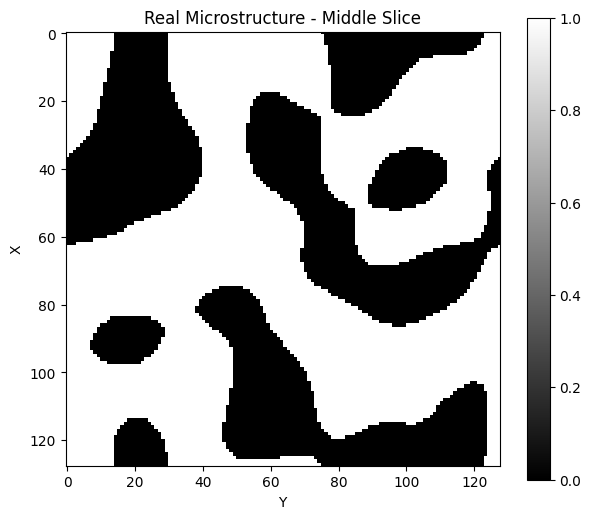

In [16]:
# ============================================================
# 2E. VISUALIZE ONE REAL MICROSTRUCTURE
# ============================================================

real_volume = train_dataset[0]

# Convert back from [-1,1] to [0,1]

real_volume = (real_volume + 1.0) / 2.0

real_volume = real_volume.squeeze().numpy()

# Choose middle Z slice

z = real_volume.shape[2] // 2


plt.figure(figsize=(7, 6))

plt.imshow(
    real_volume[:, :, z],
    cmap="gray"
)

plt.title("Real Microstructure - Middle Slice")
plt.xlabel("Y")
plt.ylabel("X")
plt.colorbar()

plt.show()

In [17]:
# ============================================================
# 3A. MODEL HYPERPARAMETERS
# ============================================================

VOLUME_SHAPE = (128, 128, 64)

LATENT_DIM = 128

CONDITION_DIM = 2

LEARNING_RATE = 2e-4

BETA1 = 0.5
BETA2 = 0.999

EPOCHS = 50

print("Volume shape :", VOLUME_SHAPE)
print("Latent dim   :", LATENT_DIM)
print("Condition dim:", CONDITION_DIM)
print("Learning rate:", LEARNING_RATE)
print("Epochs       :", EPOCHS)
print("Batch size   :", BATCH_SIZE)

Volume shape : (128, 128, 64)
Latent dim   : 128
Condition dim: 2
Learning rate: 0.0002
Epochs       : 50
Batch size   : 2


In [18]:
# ============================================================
# 3B. GENERATOR
# ============================================================

class Generator(nn.Module):

    def __init__(
        self,
        latent_dim=128,
        condition_dim=2
    ):

        super().__init__()

        self.latent_dim = latent_dim
        self.condition_dim = condition_dim

        # ----------------------------------------------------
        # Input:
        #
        # random noise z
        # +
        # one-hot condition c
        #
        # total = 128 + 2 = 130
        # ----------------------------------------------------

        input_dim = latent_dim + condition_dim

        # ----------------------------------------------------
        # Fully connected layer
        #
        # 130
        #   ↓
        # 512 × 4 × 4 × 2
        # ----------------------------------------------------

        self.fc = nn.Linear(
            input_dim,
            512 * 4 * 4 * 2
        )

        # ----------------------------------------------------
        # 4×4×2 → 8×8×4
        # ----------------------------------------------------

        self.block1 = nn.Sequential(

            nn.BatchNorm3d(512),

            nn.ReLU(True),

            nn.ConvTranspose3d(
                512,
                256,
                kernel_size=4,
                stride=2,
                padding=1
            )
        )

        # ----------------------------------------------------
        # 8×8×4 → 16×16×8
        # ----------------------------------------------------

        self.block2 = nn.Sequential(

            nn.BatchNorm3d(256),

            nn.ReLU(True),

            nn.ConvTranspose3d(
                256,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            )
        )

        # ----------------------------------------------------
        # 16×16×8 → 32×32×16
        # ----------------------------------------------------

        self.block3 = nn.Sequential(

            nn.BatchNorm3d(128),

            nn.ReLU(True),

            nn.ConvTranspose3d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            )
        )

        # ----------------------------------------------------
        # 32×32×16 → 64×64×32
        # ----------------------------------------------------

        self.block4 = nn.Sequential(

            nn.BatchNorm3d(64),

            nn.ReLU(True),

            nn.ConvTranspose3d(
                64,
                32,
                kernel_size=4,
                stride=2,
                padding=1
            )
        )

        # ----------------------------------------------------
        # 64×64×32 → 128×128×64
        # ----------------------------------------------------

        self.block5 = nn.Sequential(

            nn.BatchNorm3d(32),

            nn.ReLU(True),

            nn.ConvTranspose3d(
                32,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Tanh()
        )


    def forward(self, z, condition):

        # ----------------------------------------------------
        # Concatenate noise + one-hot condition
        # ----------------------------------------------------

        x = torch.cat(
            [z, condition],
            dim=1
        )

        # ----------------------------------------------------
        # Dense layer
        # ----------------------------------------------------

        x = self.fc(x)

        # ----------------------------------------------------
        # Reshape
        #
        # [B, 512*4*4*2]
        #
        # →
        #
        # [B, 512, 4, 4, 2]
        # ----------------------------------------------------

        x = x.view(
            -1,
            512,
            4,
            4,
            2
        )

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        x = self.block4(x)

        x = self.block5(x)

        return x

In [24]:
# ============================================================
# 3C. CORRECTED DISCRIMINATOR
# ============================================================

class Discriminator(nn.Module):

    def __init__(self, condition_dim=2):

        super().__init__()

        # 128×128×64
        #       ↓
        # 64×64×32

        self.conv1 = nn.Sequential(
            nn.Conv3d(
                1, 16,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # 64×64×32
        #       ↓
        # 32×32×16

        self.conv2 = nn.Sequential(
            nn.Conv3d(
                16, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm3d(32),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # 32×32×16
        #       ↓
        # 16×16×8

        self.conv3 = nn.Sequential(
            nn.Conv3d(
                32, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm3d(64),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # 16×16×8
        #       ↓
        # 8×8×4

        self.conv4 = nn.Sequential(
            nn.Conv3d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm3d(128),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # 8×8×4
        #       ↓
        # 4×4×2

        self.conv5 = nn.Sequential(
            nn.Conv3d(
                128, 512,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm3d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # 512 × 4 × 4 × 2 = 16384
        feature_size = 512 * 4 * 4 * 2

        self.fc = nn.Linear(
            feature_size + condition_dim,
            1
        )


    def forward(self, volume, condition):

        x = self.conv1(volume)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.flatten(start_dim=1)

        x = torch.cat(
            [x, condition],
            dim=1
        )

        return self.fc(x)

In [25]:
# ============================================================
# 3D. CREATE MODELS
# ============================================================

G = Generator(
    latent_dim=LATENT_DIM,
    condition_dim=CONDITION_DIM
).to(device)

D = Discriminator(
    condition_dim=CONDITION_DIM
).to(device)


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


print(
    "Generator parameters    :",
    f"{count_parameters(G):,}"
)

print(
    "Discriminator parameters:",
    f"{count_parameters(D):,}"
)


# ============================================================
# ADAM OPTIMIZERS
# ============================================================

optimizer_G = torch.optim.Adam(
    G.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

optimizer_D = torch.optim.Adam(
    D.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, BETA2)
)

Generator parameters    : 13,291,937
Discriminator parameters: 4,902,067


In [26]:
# ============================================================
# 4A. HINGE GAN LOSSES
# ============================================================

def discriminator_hinge_loss(
    real_logits,
    fake_logits
):

    real_loss = torch.mean(
        torch.relu(
            1.0 - real_logits
        )
    )

    fake_loss = torch.mean(
        torch.relu(
            1.0 + fake_logits
        )
    )

    return real_loss + fake_loss


def generator_hinge_loss(fake_logits):

    return -torch.mean(
        fake_logits
    )

In [22]:
# ============================================================
# 4B. ONE-HOT CONDITION
# ============================================================

def make_condition(batch_size, device):

    # --------------------------------------------------------
    # [1, 0] = two-phase microstructure
    # --------------------------------------------------------

    condition = torch.tensor(
        [1.0, 0.0],
        dtype=torch.float32,
        device=device
    )

    condition = condition.unsqueeze(0)

    condition = condition.repeat(
        batch_size,
        1
    )

    return condition

In [ ]:
real = next(iter(train_loader)).to(device)

condition = make_condition(
    real.size(0),
    device
)

with torch.no_grad():

    output = D(
        real,
        condition
    )

print("Input shape :", real.shape)
print("D output    :", output.shape)

In [ ]:
# ============================================================
# 4C. TRAINING
# ============================================================

generator_losses = []
discriminator_losses = []

val_generator_losses = []
val_discriminator_losses = []


for epoch in range(EPOCHS):

    # ========================================================
    # TRAINING MODE
    # ========================================================

    G.train()
    D.train()

    epoch_G_loss = 0.0
    epoch_D_loss = 0.0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )

    for real_volumes in progress:

        real_volumes = real_volumes.to(
            device,
            non_blocking=True
        )

        batch_size = real_volumes.size(0)


        # ====================================================
        # CONDITION
        # ====================================================

        condition = make_condition(
            batch_size,
            device
        )


        # ====================================================
        # 1. TRAIN DISCRIMINATOR
        # ====================================================

        optimizer_D.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # Real
        # ----------------------------------------------------

        real_logits = D(
            real_volumes,
            condition
        )

        # ----------------------------------------------------
        # Random latent vector
        # ----------------------------------------------------

        z = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        # ----------------------------------------------------
        # Generate fake volume
        # ----------------------------------------------------

        fake_volumes = G(
            z,
            condition
        )

        # ----------------------------------------------------
        # Detach so G isn't updated here
        # ----------------------------------------------------

        fake_logits = D(
            fake_volumes.detach(),
            condition
        )

        # ----------------------------------------------------
        # Discriminator loss
        # ----------------------------------------------------

        loss_D = discriminator_hinge_loss(
            real_logits,
            fake_logits
        )

        loss_D.backward()

        optimizer_D.step()


        # ====================================================
        # 2. TRAIN GENERATOR
        # ====================================================

        optimizer_G.zero_grad(
            set_to_none=True
        )

        # New noise
        z = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_volumes = G(
            z,
            condition
        )

        fake_logits = D(
            fake_volumes,
            condition
        )

        loss_G = generator_hinge_loss(
            fake_logits
        )

        loss_G.backward()

        optimizer_G.step()


        # ====================================================
        # RECORD
        # ====================================================

        epoch_D_loss += loss_D.item()

        epoch_G_loss += loss_G.item()


        progress.set_postfix(
            D=f"{loss_D.item():.3f}",
            G=f"{loss_G.item():.3f}"
        )


    # ========================================================
    # AVERAGE TRAINING LOSS
    # ========================================================

    epoch_D_loss /= len(train_loader)

    epoch_G_loss /= len(train_loader)


    generator_losses.append(
        epoch_G_loss
    )

    discriminator_losses.append(
        epoch_D_loss
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    G.eval()
    D.eval()

    val_G_loss = 0.0
    val_D_loss = 0.0


    with torch.no_grad():

        for real_volumes in val_loader:

            real_volumes = real_volumes.to(
                device,
                non_blocking=True
            )

            batch_size = real_volumes.size(0)

            condition = make_condition(
                batch_size,
                device
            )

            # ------------------------------------------------
            # Generate fake validation samples
            # ------------------------------------------------

            z = torch.randn(
                batch_size,
                LATENT_DIM,
                device=device
            )

            fake_volumes = G(
                z,
                condition
            )

            real_logits = D(
                real_volumes,
                condition
            )

            fake_logits = D(
                fake_volumes,
                condition
            )

            # ------------------------------------------------
            # Validation losses
            # ------------------------------------------------

            val_D = discriminator_hinge_loss(
                real_logits,
                fake_logits
            )

            val_G = generator_hinge_loss(
                fake_logits
            )

            val_D_loss += val_D.item()

            val_G_loss += val_G.item()


    val_D_loss /= len(val_loader)

    val_G_loss /= len(val_loader)


    val_generator_losses.append(
        val_G_loss
    )

    val_discriminator_losses.append(
        val_D_loss
    )


    print(
        f"\nEpoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train D: {epoch_D_loss:.4f} | "
        f"Train G: {epoch_G_loss:.4f}"
    )

    print(
        f"Val   D: {val_D_loss:.4f} | "
        f"Val   G: {val_G_loss:.4f}"
    )

Epoch 1/50:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 1/50
Train D: 1.2965 | Train G: 7.1474
Val   D: 9.1060 | Val   G: 6.7534


Epoch 2/50:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 2/50
Train D: 1.7577 | Train G: 6.8695
Val   D: 6.1099 | Val   G: -3.1290


Epoch 3/50:   0%|          | 0/41 [00:00<?, ?it/s]

...

Epoch 23/50:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 23/50
Train D: 0.4768 | Train G: 6.2697
Val   D: 2.0552 | Val   G: 2.0586


Epoch 24/50:   0%|          | 0/41 [00:00<?, ?it/s]


Epoch 24/50
Train D: 0.3409 | Train G: 6.1262
Val   D: 1.8215 | Val   G: 3.5995


Epoch 25/50:   0%|          | 0/41 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# 5. LOSS CURVES
# ============================================================

epochs_axis = np.arange(
    1,
    EPOCHS + 1
)


plt.figure(figsize=(9, 5))

plt.plot(
    epochs_axis,
    generator_losses,
    label="Generator Train"
)

plt.plot(
    epochs_axis,
    discriminator_losses,
    label="Discriminator Train"
)

plt.plot(
    epochs_axis,
    val_generator_losses,
    "--",
    label="Generator Validation"
)

plt.plot(
    epochs_axis,
    val_discriminator_losses,
    "--",
    label="Discriminator Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("3D GAN Training")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# 6A. GENERATE MICROSTRUCTURE
# ============================================================

G.eval()

with torch.no_grad():

    # --------------------------------------------------------
    # Random latent vector
    # --------------------------------------------------------

    z = torch.randn(
        1,
        LATENT_DIM,
        device=device
    )

    # --------------------------------------------------------
    # One-hot condition
    # --------------------------------------------------------

    condition = torch.tensor(
        [[1.0, 0.0]],
        dtype=torch.float32,
        device=device
    )

    # --------------------------------------------------------
    # Generate
    # --------------------------------------------------------

    generated = G(
        z,
        condition
    )

    # --------------------------------------------------------
    # Move to CPU
    # --------------------------------------------------------

    generated = generated.cpu()

    # --------------------------------------------------------
    # [-1,1] → [0,1]
    # --------------------------------------------------------

    generated = (
        generated + 1.0
    ) / 2.0

    # --------------------------------------------------------
    # Remove batch/channel dimensions
    #
    # [1,1,128,128,64]
    #
    # →
    #
    # [128,128,64]
    # --------------------------------------------------------

    generated = generated.squeeze().numpy()


# ============================================================
# THRESHOLD
# ============================================================

generated_binary = (
    generated >= 0.5
).astype(np.uint8)


print(
    "Generated shape:",
    generated_binary.shape
)

print(
    "Unique values:",
    np.unique(generated_binary)
)

print(
    "Generated volume fraction:",
    generated_binary.mean()
)

In [ ]:
# ============================================================
# 7. SAVE GENERATED SAMPLE
# ============================================================

OUTPUT_DIR = "generated_samples"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# Save binary microstructure
# ------------------------------------------------------------

binary_path = os.path.join(
    OUTPUT_DIR,
    "generated_sample_1.npy"
)

np.save(
    binary_path,
    generated_binary
)


# ------------------------------------------------------------
# Save continuous generator output
# ------------------------------------------------------------

continuous_path = os.path.join(
    OUTPUT_DIR,
    "generated_sample_1_continuous.npy"
)

np.save(
    continuous_path,
    generated
)


# ------------------------------------------------------------
# Also save as HDF5
# ------------------------------------------------------------

h5_path = os.path.join(
    OUTPUT_DIR,
    "generated_sample_1.h5"
)

with h5py.File(
    h5_path,
    "w"
) as f:

    f.create_dataset(
        "generated_sample_1",
        data=generated_binary,
        compression="gzip"
    )


print("Saved:")
print(binary_path)
print(continuous_path)
print(h5_path)

In [ ]:
# ============================================================
# 8. VISUALIZE GENERATED MICROSTRUCTURE
# ============================================================

z_index = (
    generated_binary.shape[2] // 2
)


plt.figure(figsize=(7, 6))

plt.imshow(
    generated_binary[:, :, z_index],
    cmap="gray"
)

plt.title(
    "Generated Microstructure - Middle Slice"
)

plt.xlabel("Y")
plt.ylabel("X")

plt.colorbar(
    label="Phase"
)

plt.show()

In [ ]:
# ============================================================
# 9. SAVE TRAINED MODELS
# ============================================================

torch.save(
    G.state_dict(),
    "generator_3d_microstructure.pth"
)

torch.save(
    D.state_dict(),
    "discriminator_3d_microstructure.pth"
)

print("Models saved.")